# Методы оптимизации в задаче бинарной классификации

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True
np.random.seed(42)

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
print('Размер полного датасета:', df.shape)
print('Классы:', dict(zip(range(3), iris.target_names)))
df.head()

Размер полного датасета: (150, 5)
Классы: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
mask = df['target'].isin([1, 2])
df2 = df[mask].reset_index(drop=True).copy()

#Virginica - 1, Versicolor - 0
df2['label'] = (df2['target'] == 2).astype(int)

print(df2.shape)
print(df2['label'].value_counts())
df2.head()

(100, 6)
label
0    50
1    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,label
0,7.0,3.2,4.7,1.4,1,0
1,6.4,3.2,4.5,1.5,1,0
2,6.9,3.1,4.9,1.5,1,0
3,5.5,2.3,4.0,1.3,1,0
4,6.5,2.8,4.6,1.5,1,0


In [4]:
df2[iris.feature_names].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,100.000000,100.000000,100.000000,100.000000
mean,6.262000,2.872000,4.906000,1.676000
std,0.662834,0.332751,0.825578,0.424769
min,4.900000,2.000000,3.000000,1.000000
25%,5.800000,2.700000,4.375000,1.300000
50%,6.300000,2.900000,4.900000,1.600000
75%,6.700000,3.025000,5.525000,2.000000
max,7.900000,3.800000,6.900000,2.500000


### Визуальный обзор данных

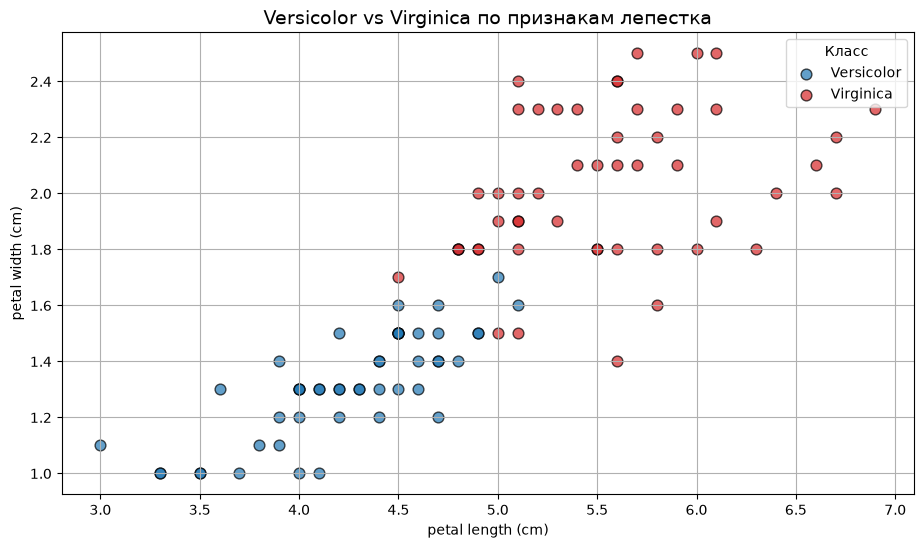

In [5]:
feat_x = 'petal length (cm)'
feat_y = 'petal width (cm)'

plt.figure(figsize=(11, 6))
for lbl, name, color in [(0, 'Versicolor', 'tab:blue'), (1, 'Virginica', 'tab:red')]:
    sub = df2[df2['label'] == lbl]
    plt.scatter(sub[feat_x], sub[feat_y], label=name, color=color, alpha=0.7, s=60, edgecolor='k')

plt.title('Versicolor vs Virginica по признакам лепестка', fontsize=14)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.legend(title='Класс')
plt.show()

На графике видно, что классы линейно **ПОЧТИ** разделимы, но есть небольшая область пересечения — то есть 100%-й точности ждать не стоит.

## 2. Логистическая регрессия

### Реализация в виде класса

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


class LogisticRegressionCustom:
    def __init__(self, lr=0.1, n_iter=2000, optimizer='gd',
                 beta=0.9, beta1=0.9, beta2=0.999, eps=1e-8, seed=42):
        self.lr = lr
        self.n_iter = n_iter
        self.optimizer = optimizer
        self.beta = beta           # RMSProp
        self.beta1 = beta1         # Nadam (момент)
        self.beta2 = beta2         # Nadam (масштаб)
        self.eps = eps
        self.seed = seed

    @staticmethod
    def _log_loss(y, p):
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape

        rng = np.random.default_rng(self.seed)
        self.w = rng.normal(0, 0.01, d)
        self.b = 0.0
        self.loss_history = []

        Sw = np.zeros(d); Sb = 0.0                     # RMSProp
        mw = np.zeros(d); vw = np.zeros(d)             # Nadam (веса)
        mb = 0.0;         vb = 0.0                     # Nadam (bias)

        for t in range(1, self.n_iter + 1):
            p = sigmoid(X @ self.w + self.b)
            gw = X.T @ (p - y) / n
            gb = np.mean(p - y)

            if self.optimizer == 'gd':
                self.w -= self.lr * gw
                self.b -= self.lr * gb

            elif self.optimizer == 'rmsprop':
                Sw = self.beta * Sw + (1 - self.beta) * gw**2
                Sb = self.beta * Sb + (1 - self.beta) * gb**2
                self.w -= self.lr * gw / (np.sqrt(Sw) + self.eps)
                self.b -= self.lr * gb / (np.sqrt(Sb) + self.eps)

            elif self.optimizer == 'nadam':
                mw = self.beta1 * mw + (1 - self.beta1) * gw
                vw = self.beta2 * vw + (1 - self.beta2) * gw**2
                mb = self.beta1 * mb + (1 - self.beta1) * gb
                vb = self.beta2 * vb + (1 - self.beta2) * gb**2

                mw_h = mw / (1 - self.beta1**t); vw_h = vw / (1 - self.beta2**t)
                mb_h = mb / (1 - self.beta1**t); vb_h = vb / (1 - self.beta2**t)

                nesterov_w = self.beta1 * mw_h + (1 - self.beta1) * gw / (1 - self.beta1**t)
                nesterov_b = self.beta1 * mb_h + (1 - self.beta1) * gb / (1 - self.beta1**t)

                self.w -= self.lr * nesterov_w / (np.sqrt(vw_h) + self.eps)
                self.b -= self.lr * nesterov_b / (np.sqrt(vb_h) + self.eps)
            else:
                raise ValueError(f"Неизвестный оптимизатор: {self.optimizer}")

            self.loss_history.append(self._log_loss(y, p))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Метрика качества и подготовка данных

В качестве метрики используем **accuracy**.

In [7]:
def accuracy(y_true, y_pred):
    return np.mean(np.asarray(y_true) == np.asarray(y_pred))


X = df2[iris.feature_names].values
y = df2['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка: (70, 4)
Тестовая выборка:  (30, 4)


## 3. Градиентный спуск

In [8]:
results = {}

t0 = time.perf_counter()
model_gd = LogisticRegressionCustom(lr=0.1, n_iter=2000, optimizer='gd')
model_gd.fit(X_train, y_train)
elapsed_gd = time.perf_counter() - t0

acc_train = accuracy(y_train, model_gd.predict(X_train))
acc_test = accuracy(y_test, model_gd.predict(X_test))
results['Gradient Descent'] = {'train': acc_train, 'test': acc_test,
                               'loss': model_gd.loss_history[-1], 'time': elapsed_gd}

print(f"Gradient Descent")
print(f"  Accuracy (train): {acc_train:.4f}")
print(f"  Accuracy (test):  {acc_test:.4f}")
print(f"  Итоговый loss:    {model_gd.loss_history[-1]:.4f}")
print(f"  Время обучения:   {elapsed_gd*1000:.1f} мс")

Gradient Descent
  Accuracy (train): 0.9571
  Accuracy (test):  0.9667
  Итоговый loss:    0.0680
  Время обучения:   72.2 мс


## 4. RMSProp (Root Mean Square Propagation)

In [9]:
t0 = time.perf_counter()
model_rms = LogisticRegressionCustom(lr=0.01, n_iter=2000, optimizer='rmsprop', beta=0.9)
model_rms.fit(X_train, y_train)
elapsed_rms = time.perf_counter() - t0

acc_train = accuracy(y_train, model_rms.predict(X_train))
acc_test = accuracy(y_test, model_rms.predict(X_test))
results['RMSProp'] = {'train': acc_train, 'test': acc_test,
                      'loss': model_rms.loss_history[-1], 'time': elapsed_rms}

print(f"RMSProp")
print(f"  Accuracy (train): {acc_train:.4f}")
print(f"  Accuracy (test):  {acc_test:.4f}")
print(f"  Итоговый loss:    {model_rms.loss_history[-1]:.4f}")
print(f"  Время обучения:   {elapsed_rms*1000:.1f} мс")

RMSProp
  Accuracy (train): 0.9571
  Accuracy (test):  0.9667
  Итоговый loss:    0.0604
  Время обучения:   104.6 мс


## 5. Nadam (Nesterov-accelerated Adaptive Moment Estimation)

In [10]:
t0 = time.perf_counter()
model_nadam = LogisticRegressionCustom(lr=0.01, n_iter=2000, optimizer='nadam',
                                       beta1=0.9, beta2=0.999)
model_nadam.fit(X_train, y_train)
elapsed_nadam = time.perf_counter() - t0

acc_train = accuracy(y_train, model_nadam.predict(X_train))
acc_test = accuracy(y_test, model_nadam.predict(X_test))
results['Nadam'] = {'train': acc_train, 'test': acc_test,
                    'loss': model_nadam.loss_history[-1], 'time': elapsed_nadam}

print(f"Nadam")
print(f"  Accuracy (train): {acc_train:.4f}")
print(f"  Accuracy (test):  {acc_test:.4f}")
print(f"  Итоговый loss:    {model_nadam.loss_history[-1]:.4f}")
print(f"  Время обучения:   {elapsed_nadam*1000:.1f} мс")

Nadam
  Accuracy (train): 0.9571
  Accuracy (test):  0.9667
  Итоговый loss:    0.0640
  Время обучения:   120.0 мс


## 6. Сравнение методов

In [11]:
table = pd.DataFrame([
    {'Метод': name,
     'Accuracy (train)': round(r['train'], 4),
     'Accuracy (test)': round(r['test'], 4),
     'Итоговый loss': round(r['loss'], 4),
     'Время, мс': round(r['time'] * 1000, 1)}
    for name, r in results.items()
])
table

,Метод,Accuracy (train),Accuracy (test),Итоговый loss,"Время, мс"
0,Gradient Descent,0.9571,0.9667,0.0680,72.2
1,RMSProp,0.9571,0.9667,0.0604,104.6
2,Nadam,0.9571,0.9667,0.0640,120.0


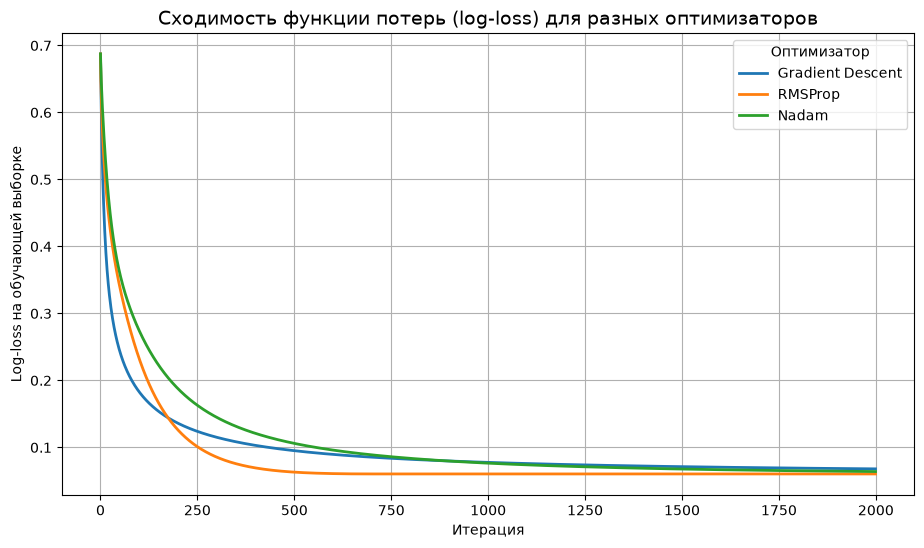

In [12]:
plt.figure(figsize=(11, 6))
plt.plot(model_gd.loss_history, label='Gradient Descent', linewidth=2)
plt.plot(model_rms.loss_history, label='RMSProp', linewidth=2)
plt.plot(model_nadam.loss_history, label='Nadam', linewidth=2)

plt.title('Сходимость функции потерь (log-loss) для разных оптимизаторов', fontsize=14)
plt.xlabel('Итерация')
plt.ylabel('Log-loss на обучающей выборке')
plt.legend(title='Оптимизатор')
plt.show()

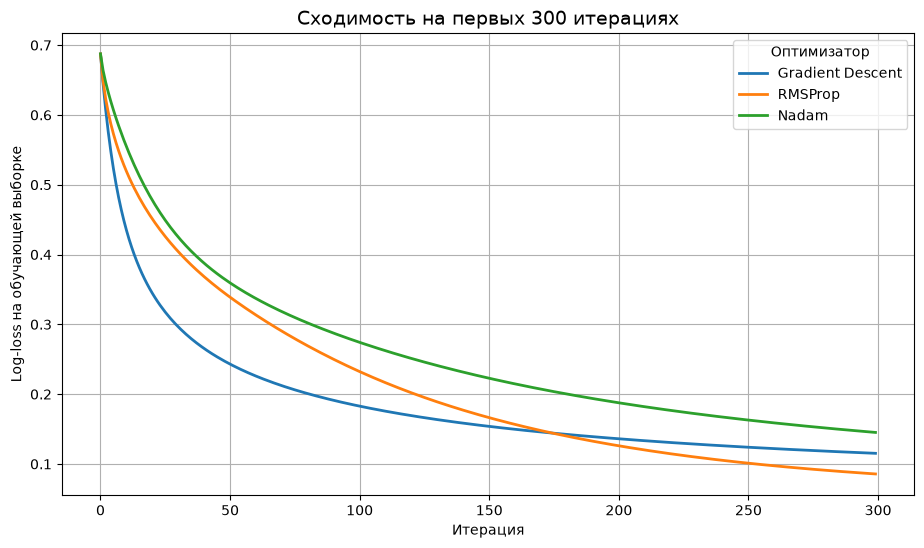

In [13]:
plt.figure(figsize=(11, 6))
n_show = 300
plt.plot(model_gd.loss_history[:n_show], label='Gradient Descent', linewidth=2)
plt.plot(model_rms.loss_history[:n_show], label='RMSProp', linewidth=2)
plt.plot(model_nadam.loss_history[:n_show], label='Nadam', linewidth=2)

plt.title(f'Сходимость на первых {n_show} итерациях', fontsize=14)
plt.xlabel('Итерация')
plt.ylabel('Log-loss на обучающей выборке')
plt.legend(title='Оптимизатор')
plt.show()

## Вывод

**По качеству классификации** все три метода оптимизации достигли одинаковой accuracy на тестовой выборке (~0.97). Скорее всего потому что задача простая и почти линейно разделимая, поэтому при достаточном числе итераций любой корректный метод сходится к одному и тому же оптимуму логистической регрессии. Одиночная ошибка на тесте приходится на объект из зоны пересечения классов Versicolor/Virginica.

**По скорости сходимости** методы различаются заметно:

- **Gradient Descent** снижает потери плавно и монотонно, но медленнее всех — фиксированный шаг одинаков для всех параметров.
- **RMSProp** за счёт адаптивного (индивидуального для каждого параметра) масштабирования шага стартует резче и раньше выходит на плато.
- **Nadam** сочетает адаптивный масштаб и момент Нестерова, что даёт быстрый старт; на простой задаче его преимущество перед RMSProp невелико, но именно такие методы дают выигрыш на сложных, «овражных» функциях потерь.